## Invoking a subhgraph from a node in main graph

<pre>
Here we will make 2 flows:

Example flow:-
Start --> User Query --> English Answer --> Hindi Answer --> END

Graph 1 (MAIN Flow):-
START --> GENERATE ANSWER --> TRANSLATE ANSWER --> END

Subgraph:-
START --> TRANSLATE NODE (English to Hindi) --> END

Here we will call Subgraph in Translate Answer node by invoke 
Also here there will be two different State here one for Parent Graph and one for Sub Graph
</pre>

In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict,Literal,Annotated
from dotenv import load_dotenv
from pydantic import BaseModel,Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_openai import ChatOpenAI
load_dotenv()

True

# Subgraph

In [2]:
subgraph_llm = ChatOpenAI(model="gpt-4")

In [3]:
class SubgraphState(TypedDict):
    input_text: str
    translation_hindi:str

In [4]:
def translate(state:SubgraphState):

    prompt = f"""Translate the given text into Hindi
                Make sure you are accurate at translating the text to Hindi and do not add any unecessary data
                Text: {state['input_text']}""".strip()

    hindi_text = subgraph_llm.invoke(prompt).content

    return {'translation_hindi':hindi_text}

In [5]:
subgraph = StateGraph(SubgraphState)

In [6]:
subgraph.add_node('translate',translate)

In [7]:
subgraph.add_edge(START,'translate')
subgraph.add_edge('translate',END)

In [8]:
workflow = subgraph.compile()

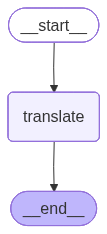

In [9]:
workflow

In [10]:
op = workflow.invoke({'input_text':"What is Cloud"})

print(op)

{'input_text': 'What is Cloud', 'translation_hindi': 'टेक्स्ट: बादल क्या है?'}


# Main Graph

In [11]:
parent_llm = ChatOpenAI(model="gpt-4")

In [12]:
class ParentGraph(TypedDict):
    query : str
    answer : str
    hindi : str

In [13]:
def QA(state:ParentGraph):

    ans = parent_llm.invoke(state['query']).content

    return {'answer':ans}

In [14]:
def translate_parent(state:ParentGraph):

    hindi = workflow.invoke({'input_text':state['answer']})

    return {'hindi':hindi['translation_hindi']}

In [15]:
parent_graph = StateGraph(ParentGraph)

In [16]:
parent_graph.add_node('qa',QA)
parent_graph.add_node('translate_parent',translate_parent)

In [17]:
parent_graph.add_edge(START,'qa')
parent_graph.add_edge('qa','translate_parent')
parent_graph.add_edge('translate_parent',END)

In [18]:
main_workflow = parent_graph.compile()

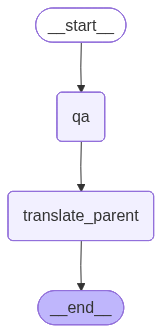

In [19]:
main_workflow

In [20]:
ans = main_workflow.invoke({'query':"What is Cloud"})
ans

{'query': 'What is Cloud',
 'answer': 'Cloud computing is the delivery of different services through the Internet, including data storage, servers, databases, networking, and software. Instead of keeping files on a proprietary hard drive or local storage device, cloud-based storage makes it possible to save them to a remote database. As long as an electronic device has access to the web, it has access to the data and the software programs to run it.',
 'hindi': 'बादल कंप्यूटिंग इंटरनेट के माध्यम से विभिन्न सेवाओं की वितरण है, जिसमें डेटा संग्रहण, सर्वर, डेटाबेस, नेटवर्किंग और सॉफ्टवेयर शामिल हैं। स्वतंत्र हार्ड ड्राइव या स्थानीय संग्रहण उपकरण पर फ़ाइलों को रखने के बजाय, बादल-आधारित संग्रहण उन्हें एक दूरस्थ डेटाबेस में सहेजने की संभावना बनाता है। जब तक कि एक इलेक्ट्रॉनिक उपकरण को वेब का उपयोग करने की अनुमति है, उसके पास डेटा और सॉफ्टवेयर कार्यक्रमों को चलाने की पहुंच होती है।'}